In [25]:
import subprocess
import importlib
libraries = ['shap','lime','ucimlrepo']
for lib in libraries:
    spec = importlib.util.find_spec(lib)
    if spec is None:
        # If the library isn't installed, install it
        print(f"{lib} is not installed. Installing...")
        subprocess.check_call(["pip", "install", lib])
        print(f"{lib} has been installed.\n")
    else:
        print(f"{lib} is installed.")

shap is installed.
lime is installed.
ucimlrepo is installed.


In [26]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
import shap
import lime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# In the dataframe y (labels) there are these unique values: ['<=50K' '>50K' '<=50K.' '>50K.']
# We are going to delate the dot (.)
y['income'] = y['income'].str.replace('.', '')

features_encoder = OrdinalEncoder()
label_encoder = LabelEncoder()
X_columns = X.columns
y_columns = y.columns

X = features_encoder.fit_transform(X)
X = pd.DataFrame(X, columns=X_columns)

y = label_encoder.fit_transform(y)
y = pd.DataFrame(y, columns=y_columns)

In [28]:
X.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [29]:
knn_imputer = ColumnTransformer([('Inputer knn', KNNImputer(n_neighbors=5, weights="distance"), ['workclass', 'occupation', 'native-country'])],
                                remainder='passthrough', verbose_feature_names_out=False, n_jobs=-1)
knn_imputer.set_output(transform='pandas')
X = knn_imputer.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [31]:
tree = RandomForestClassifier(n_estimators=100, random_state=10)
clf = tree.fit(X_train, y_train.values.ravel())

## A) Calcule las atribuciones locales de las 200 primeras instancias del conjunto de datos de test (X_test[:200]):

In [32]:
exp_test = X_test[:200]

### TreeSHAP

In [33]:
explainer_tree = shap.TreeExplainer(clf)
attributions_tree = explainer_tree.shap_values(exp_test)

(2, 200, 14)


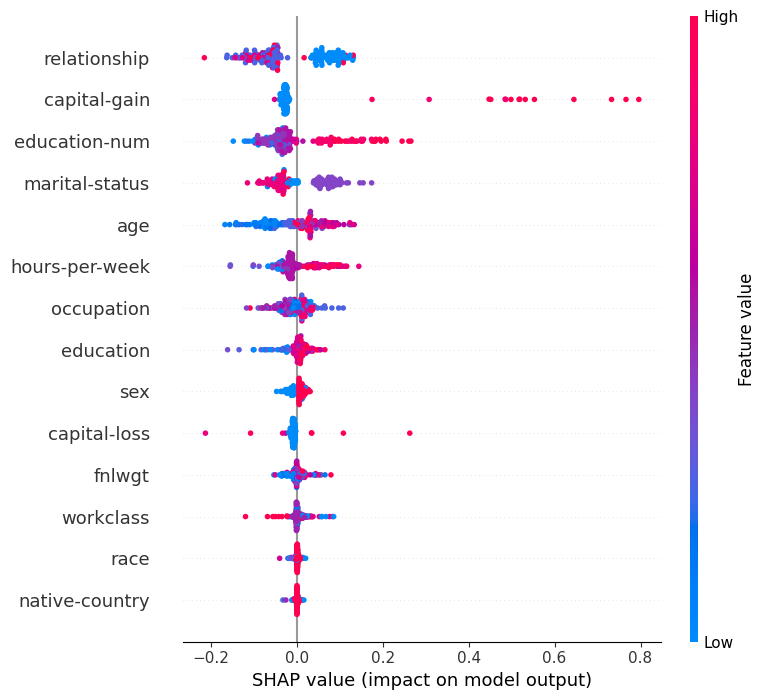

In [34]:
print(np.shape(attributions_tree))
shap.summary_plot(attributions_tree[1], exp_test)

### KernelSHAP

In [ ]:
explainer_kernel = shap.KernelExplainer(clf.predict, shap.sample(X_train, 50))
attributions_kernel = explainer_kernel.shap_values(exp_test)

  0%|          | 0/200 [00:00<?, ?it/s]

(200, 14)


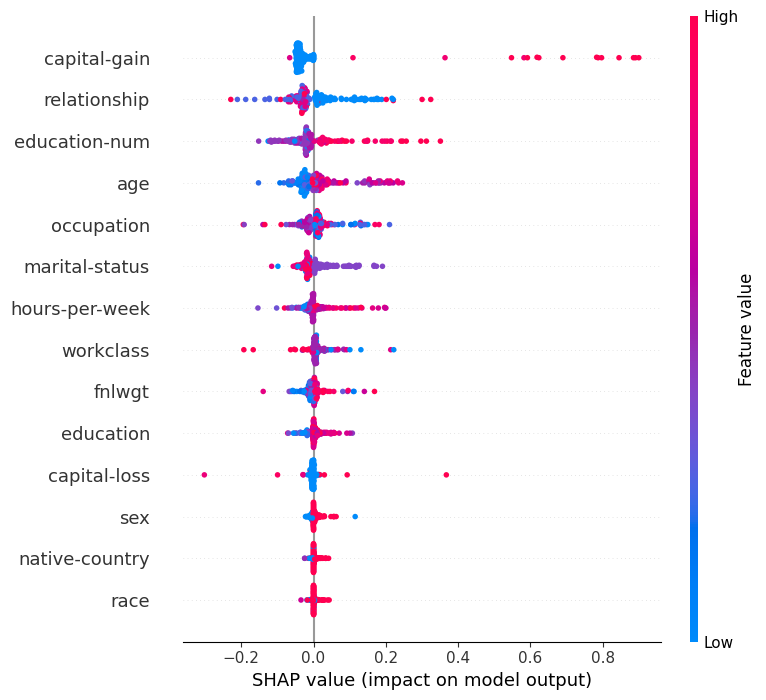

In [ ]:
print(np.shape(attributions_kernel))
shap.summary_plot(attributions_kernel, exp_test)

### LIME

In [ ]:
import warnings
warnings.filterwarnings("ignore")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train.values)
attributions_lime = []
exp_size = exp_test.shape[0]
for i in range(exp_size):
  attribution_lime = explainer_lime.explain_instance(exp_test.values[i], clf.predict_proba, num_features=len(X_test.columns))
  attributions_lime.append(attribution_lime.local_exp[1])

print('Prediction:', clf.predict([exp_test.values[1]]))
print(np.shape(attributions_lime))

Prediction: [1]
(200, 14, 2)


In [ ]:
print(attribution_lime.local_exp[1])

[(11, -0.22299287296020404), (13, -0.0964965407385376), (6, -0.09087657978842992), (7, -0.0729312562622278), (12, -0.06544206593903253), (8, -0.057489927921674726), (1, -0.015252159023297166), (5, 0.01247781875328054), (10, -0.011172236166023867), (0, -0.009945030311977047), (3, -0.006317323497892074), (4, -0.002443732783023087), (2, -0.0007776624173688449), (9, 0.0)]


Estan desordenadas, imprimimos para ver si afecta

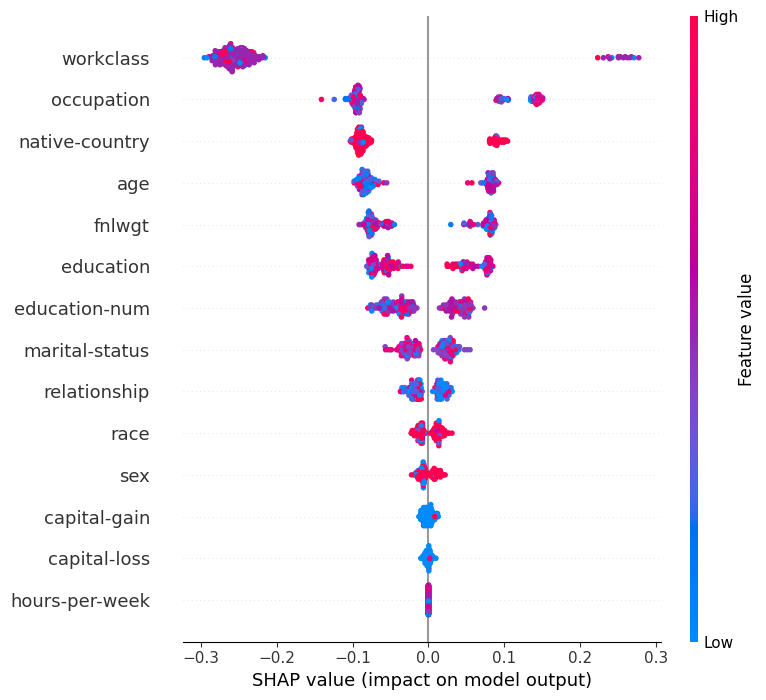

In [ ]:
npattrib = np.array(attributions_lime)
shap.summary_plot(npattrib[:,:,1], exp_test)

Ordenamos cada atribución local en base al número de las variables porque el orden parece relevante para este método

In [ ]:
att_lime_summary = []
for at in attributions_lime:
  sorted_data = sorted(at, key=lambda x: x[0])
  att_lime_summary.append([x[1] for x in sorted_data])

npattrib = np.array(att_lime_summary)
print(np.shape(npattrib))

(200, 14)


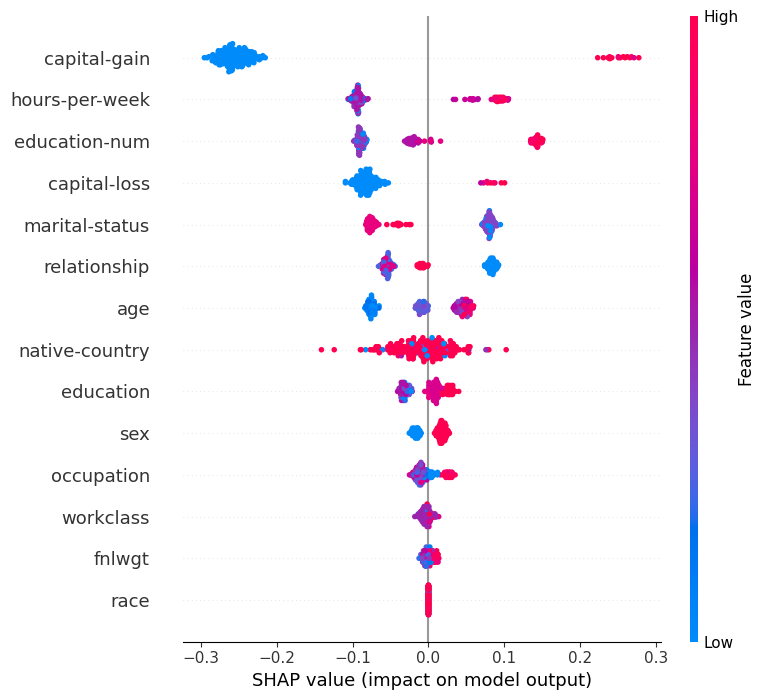

In [ ]:
shap.summary_plot(npattrib, exp_test)

## B) Visualice las atribuciones de cada método para las características "Edad" y "Horas por semana" con un gráfico de dispersión, colocando el valor de la característica en el eje x y la atribución de la característica en el eje y. Utilice la biblioteca matplotlib para generar los gráficos. Sobre la base de estos gráficos, ¿qué observaciones puede hacer sobre cómo se relacionan estas características con la predicción de ingresos del modelo?

### TreeSHAP, KernelSHAP y LIME

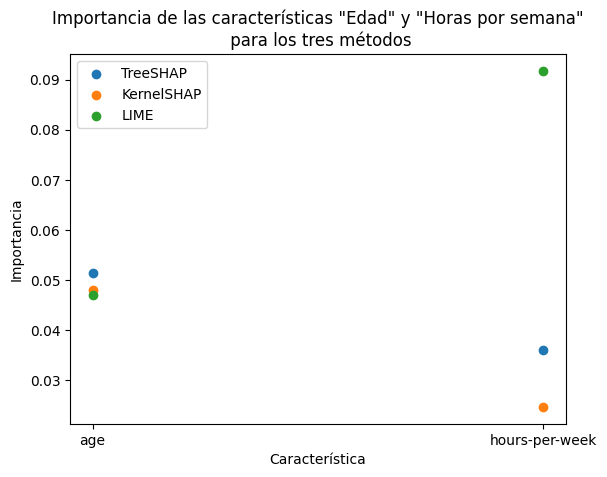

In [ ]:
features_to_plot = ['age', 'hours-per-week']
selected_feature_indices = [X_test.columns.get_loc(feature) for feature in features_to_plot]

selected_shap_values_tree = np.abs(attributions_tree[1][:, selected_feature_indices])
feature_importance_tree = np.abs(selected_shap_values_tree).mean(axis=0)

selected_shap_values_kernel = np.abs(attributions_kernel[:, selected_feature_indices])
feature_importance_kernel = np.abs(selected_shap_values_kernel).mean(axis=0)

selected_shap_values_lime = np.abs(npattrib[:, selected_feature_indices])
feature_importance_lime = np.abs(selected_shap_values_lime).mean(axis=0)

plt.scatter(features_to_plot, feature_importance_tree, label="TreeSHAP")
plt.scatter(features_to_plot, feature_importance_kernel, label="KernelSHAP")
plt.scatter(features_to_plot, feature_importance_lime, label="LIME")

plt.xlabel('Característica')
plt.ylabel('Importancia')
plt.title('Importancia de las características "Edad" y "Horas por semana"\n para los tres métodos')


plt.legend()
plt.show()



Como podemos ver, para el caso de la característica "Edad", se obtiene una importancia similar utilizando los tres métodos.

Sin embargo, en el caso de la característica "Horas por semana", vemos que los valores difieren para cada uno de los métodos. En el caso de LIME, esta variable cobra más importancia, con un valor de casi 0.1, frente a TreeSHAP y KernelSHAP, con valores de 0.035 y 0.025 respectivamente.

En el caso de LIME, la variable "hours-per-week" tiene mayor influencia en la predicción de los ingresos que en los métodos SHAP.





## C) Visualice las atribuciones de cada método para la muestra con índice 1 en el conjunto de prueba (X_test.iloc[1]) mediante un gráfico de barras, con los nombres de las características en el eje y, y las atribuciones de las características en el eje x . A partir de las atribuciones TreeSHAP, describa una característica que contribuya de forma muy positiva a la predicción de esta muestra a la predicción de esta muestra y otra que tenga una contribución negativa importante.

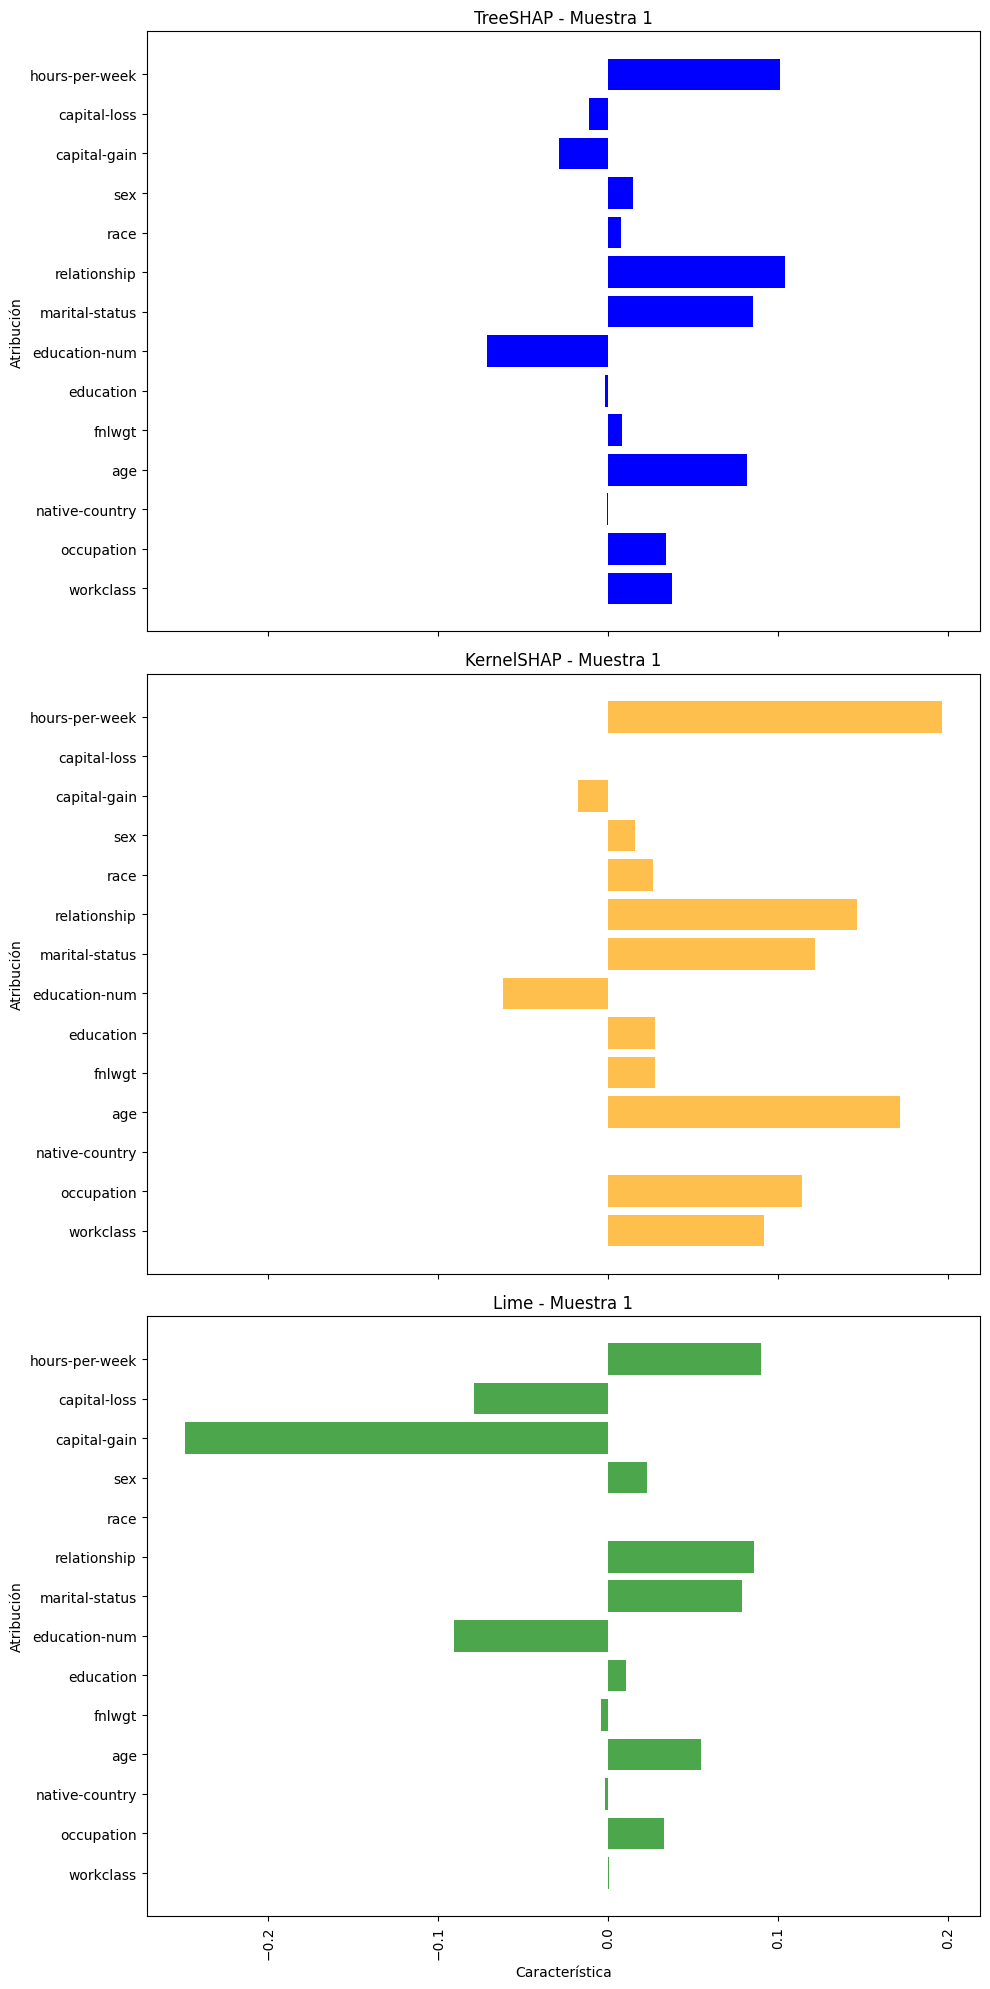

In [ ]:
sample_index = 1
sample = X_test.iloc[sample_index]

# Calcular atribuciones para la muestra con índice 1
attributions_tree_sample = attributions_tree[1][sample_index]
attributions_kernel_sample = attributions_kernel[sample_index]
attributions_lime_sample = npattrib[sample_index]

# Obtener nombres de características
feature_names = X_test.columns


# Crear tres gráficos de barras para visualizar las atribuciones de cada método
fig, axes = plt.subplots(3, 1, figsize=(10, 20), sharex=True)

# Gráfico para TreeSHAP
axes[0].barh(feature_names, attributions_tree_sample, color='blue')
axes[0].set_ylabel('Atribución')
axes[0].set_title('TreeSHAP - Muestra ' + str(sample_index))

# Gráfico para KernelSHAP
axes[1].barh(feature_names, attributions_kernel_sample, color='orange', alpha=0.7)
axes[1].set_ylabel('Atribución')
axes[1].set_title('KernelSHAP - Muestra ' + str(sample_index))

# Gráfico para Lime
axes[2].barh(feature_names, attributions_lime_sample, color='green', alpha=0.7)
axes[2].set_xlabel('Característica')
axes[2].set_ylabel('Atribución')
axes[2].set_title('Lime - Muestra ' + str(sample_index))

# Rotar los nombres de las características en el eje x
for ax in axes:
    ax.tick_params(axis='x', rotation=90, labelsize=10)

plt.tight_layout()
plt.show()

* TreeSHAP: Una característica que contribuye positivamente de forma considerable es "relationship". Entre las que más constribuyen negativamente, está "education-num".
* KernelSHAP: La característica con mayor influencia positiva es "hours-per-week". La que tiene mayor influencia negativa es "education-num".
* LIME: La característica con mayor influencia positiva es "hours-per-week". La que tiene mayor influencia negativa es "capital-gain".





## D) Un parámetro importante para KernelSHAP es el número de muestras (el argumento nsamples en la función la función shap values() de KernelExplainer). Si se utilizan más muestras, mejorará la calidad del resultado final de atribución de características, pero es más costoso. En las partes anteriores de este problema, utilizamos la configuración por defecto de este parámetro (véase aquí). Para investigar este parámetro, ejecute KernelSHAP2 para la muestra con índice 1 en el conjunto de prueba (X_test.iloc[1]) con nsamples=10, nsamples=100 y nsamples=1000 para 10 ejecuciones cada uno. Una vez más, utilice un gráfico de barras para atribuciones de características locales, pero esta vez incluya barras de error para representar la desviación estándar entre ejecuciones de las atribuciones de características locales para cada número de muestras. Explique el resultado.


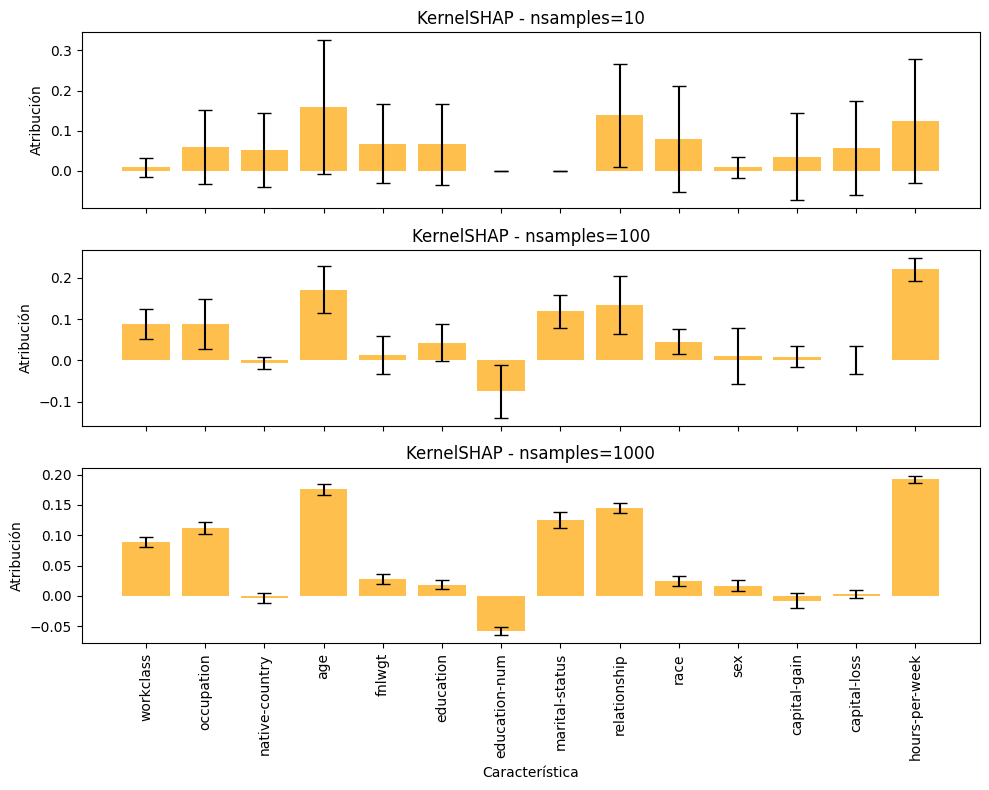

In [ ]:
sample_index = 1
sample = X_test.iloc[sample_index]


num_runs = 10
nsamples_values = [10, 100, 1000]

attributions_runs = {nsamples: [] for nsamples in nsamples_values}


for nsamples in nsamples_values:
    for _ in range(num_runs):

        attributions_kernel = explainer_kernel.shap_values(sample, nsamples=nsamples)
        attributions_runs[nsamples].append(attributions_kernel)


mean_attributions = {nsamples: np.mean(attributions_runs[nsamples], axis=0) for nsamples in nsamples_values}
std_dev_attributions = {nsamples: np.std(attributions_runs[nsamples], axis=0) for nsamples in nsamples_values}


feature_names = X_test.columns


fig, axes = plt.subplots(len(nsamples_values), 1, figsize=(10, 8), sharex=True)

for i, nsamples in enumerate(nsamples_values):
    ax = axes[i]
    ax.bar(feature_names, mean_attributions[nsamples], yerr=std_dev_attributions[nsamples], capsize=5, color='orange', alpha=0.7)
    ax.set_ylabel('Atribución')
    ax.set_title(f'KernelSHAP - nsamples={nsamples}')

for ax in axes:
    ax.tick_params(axis='x', rotation=90, labelsize=10)
plt.xlabel('Característica')
plt.tight_layout()
plt.show()

Observamos que al incrementar el número de muestras, la precisión del intervalo de confianza mejora respecto a la importancia de cada característica. Cuando nsamples=10, las barras de error resultan demasiado grandes para obtener una aproximación fiable. Conforme aumentamos el número de muestras, los intervalos de confianza se reducen progresivamente, llegando a rangos muy estrechos, como en el caso de nsamples=1000.